# Data Creation — Synthetic Clock Dataset

בשלב זה ניצור דאטה סינטטי חדש ומבוקר.

כל דוגמה כוללת:
1. שעון דיגיטלי
2. שעון אנלוגי עם מחוגים
3. אותו שעון אנלוגי בלי מחוגים
4. labels.csv עם השעה, הנתיבים והסגנון

נשתמש ב־5 סגנונות קבועים כדי ליצור גיוון מבוקר.

In [84]:
import math
import random
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

In [85]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"

DIGITAL_DIR = DATA_DIR / "digital"
ANALOG_WITH_HANDS_DIR = DATA_DIR / "analog_with_hands"
ANALOG_CLEAN_DIR = DATA_DIR / "analog_clean"

for folder in [DIGITAL_DIR, ANALOG_WITH_HANDS_DIR, ANALOG_CLEAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders are ready")

Folders are ready


In [86]:
ROMAN_NUMERALS = {
    1: "I", 2: "II", 3: "III", 4: "IV",
    5: "V", 6: "VI", 7: "VII", 8: "VIII",
    9: "IX", 10: "X", 11: "XI", 12: "XII"
}

CLOCK_STYLES = [
    {
        "style_name": "classic_light",
        "background": (240, 240, 240),
        "face_color": (255, 255, 255),
        "outline_color": (0, 0, 0),
        "outline_width": 4,
        "mark_color": (0, 0, 0),
        "number_color": (0, 0, 0),
        "numeral_type": "arabic",
        "number_font_size": 18,
        "hour_hand_color": (0, 0, 0),
        "minute_hand_color": (0, 0, 0),
        "second_hand_color": (200, 0, 0),
        "hand_style": "simple",
        "radius": 90
    },
    {
        "style_name": "dark_mode",
        "background": (30, 30, 30),
        "face_color": (45, 45, 45),
        "outline_color": (255, 255, 255),
        "outline_width": 4,
        "mark_color": (255, 255, 255),
        "number_color": (255, 255, 255),
        "numeral_type": "arabic",
        "number_font_size": 18,
        "hour_hand_color": (255, 255, 255),
        "minute_hand_color": (255, 255, 255),
        "second_hand_color": (255, 60, 60),
        "hand_style": "simple",
        "radius": 88
    },
    {
        "style_name": "gold_roman",
        "background": (245, 235, 210),
        "face_color": (255, 248, 225),
        "outline_color": (120, 90, 40),
        "outline_width": 5,
        "mark_color": (120, 90, 40),
        "number_color": (120, 90, 40),
        "numeral_type": "roman",
        "number_font_size": 17,
        "hour_hand_color": (0, 0, 0),
        "minute_hand_color": (0, 0, 0),
        "second_hand_color": (180, 0, 0),
        "hand_style": "thick",
        "radius": 90
    },
    {
        "style_name": "minimal_blue",
        "background": (230, 240, 255),
        "face_color": (245, 250, 255),
        "outline_color": (30, 60, 120),
        "outline_width": 4,
        "mark_color": (30, 60, 120),
        "number_color": (30, 60, 120),
        "numeral_type": "none",
        "number_font_size": 16,
        "hour_hand_color": (20, 20, 20),
        "minute_hand_color": (20, 20, 20),
        "second_hand_color": (200, 50, 50),
        "hand_style": "modern",
        "radius": 88
    },
    {
        "style_name": "clean_white",
        "background": (255, 255, 255),
        "face_color": (255, 255, 255),
        "outline_color": (80, 80, 80),
        "outline_width": 3,
        "mark_color": (80, 80, 80),
        "number_color": (80, 80, 80),
        "numeral_type": "arabic",
        "number_font_size": 18,
        "hour_hand_color": (0, 0, 0),
        "minute_hand_color": (0, 0, 0),
        "second_hand_color": (255, 0, 0),
        "hand_style": "thin",
        "radius": 90
    }
]

def random_clock_style():
    return random.choice(CLOCK_STYLES)

יצירת שעון דיגיטלי

In [87]:
def create_digital_clock_image(hour, minute, second, image_size=224):
    bg_colors = [
        (5, 5, 5),
        (15, 15, 20),
        (0, 20, 15),
        (20, 10, 10),
        (8, 8, 25)
    ]

    digit_colors = [
        (0, 255, 120),
        (0, 220, 255),
        (255, 80, 80),
        (255, 220, 80),
        (220, 220, 255)
    ]

    img = Image.new("RGB", (image_size, image_size), color=random.choice(bg_colors))
    draw = ImageDraw.Draw(img)

    time_text = f"{hour:02d}:{minute:02d}:{second:02d}"

    try:
        font = ImageFont.truetype("arial.ttf", random.choice([36, 38, 40, 42, 44]))
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), time_text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (image_size - text_width) // 2
    y = (image_size - text_height) // 2

    draw.rounded_rectangle(
        [18, 68, image_size - 18, 156],
        radius=12,
        fill=(0, 0, 0),
        outline=(60, 60, 60),
        width=3
    )

    draw.text((x, y), time_text, fill=random.choice(digit_colors), font=font)

    return img

יצירת שעון אנלוגי

In [88]:
def draw_hand(draw, center, angle_deg, length, color, width, style_name="simple"):
    cx, cy = center
    angle = math.radians(angle_deg - 90)

    x = cx + length * math.cos(angle)
    y = cy + length * math.sin(angle)

    if style_name == "thin":
        draw.line([cx, cy, x, y], fill=color, width=max(1, width - 2))
    elif style_name == "thick":
        draw.line([cx, cy, x, y], fill=color, width=width + 2)
    elif style_name == "modern":
        back_length = 12
        bx = cx - back_length * math.cos(angle)
        by = cy - back_length * math.sin(angle)
        draw.line([bx, by, x, y], fill=color, width=width)
    else:
        draw.line([cx, cy, x, y], fill=color, width=width)


def draw_clock_face(draw, center, style):
    cx, cy = center
    radius = style["radius"]

    draw.ellipse(
        [cx - radius, cy - radius, cx + radius, cy + radius],
        outline=style["outline_color"],
        width=style["outline_width"],
        fill=style["face_color"]
    )

    for i in range(60):
        angle = math.radians(i * 6 - 90)

        if i % 5 == 0:
            inner = radius - 15
            width = 3
        else:
            inner = radius - 7
            width = 1

        x1 = cx + inner * math.cos(angle)
        y1 = cy + inner * math.sin(angle)
        x2 = cx + radius * math.cos(angle)
        y2 = cy + radius * math.sin(angle)

        draw.line([x1, y1, x2, y2], fill=style["mark_color"], width=width)

    if style["numeral_type"] != "none":
        try:
            font = ImageFont.truetype("arial.ttf", style["number_font_size"])
        except:
            font = ImageFont.load_default()

        for number in range(1, 13):
            angle = math.radians(number * 30 - 90)
            number_radius = radius - 32

            text = ROMAN_NUMERALS[number] if style["numeral_type"] == "roman" else str(number)

            bbox = draw.textbbox((0, 0), text, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]

            x = cx + number_radius * math.cos(angle) - tw / 2
            y = cy + number_radius * math.sin(angle) - th / 2

            draw.text((x, y), text, fill=style["number_color"], font=font)


def create_analog_clock_image(hour, minute, second, image_size=224, with_hands=True, style=None):
    if style is None:
        style = random_clock_style()

    img = Image.new("RGB", (image_size, image_size), color=style["background"])
    draw = ImageDraw.Draw(img)

    center = (image_size // 2, image_size // 2)

    draw_clock_face(draw, center, style)

    if with_hands:
        radius = style["radius"]

        hour_angle = ((hour % 12) + minute / 60) * 30
        minute_angle = (minute + second / 60) * 6
        second_angle = second * 6

        draw_hand(draw, center, hour_angle, radius * 0.50, style["hour_hand_color"], 6, style["hand_style"])
        draw_hand(draw, center, minute_angle, radius * 0.72, style["minute_hand_color"], 4, style["hand_style"])
        draw_hand(draw, center, second_angle, radius * 0.82, style["second_hand_color"], 2, "thin")

        cx, cy = center
        draw.ellipse([cx - 5, cy - 5, cx + 5, cy + 5], fill=style["hour_hand_color"])

    return img

sample check

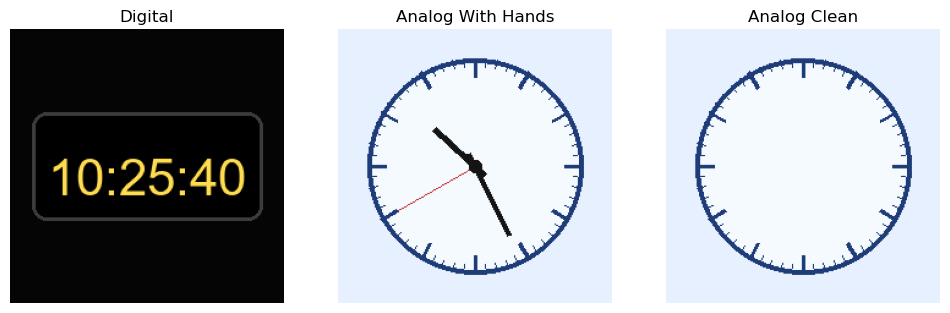

Style used: minimal_blue


In [89]:
hour, minute, second = 10, 25, 40

digital_img = create_digital_clock_image(hour, minute, second)

style = random_clock_style()

analog_hands_img = create_analog_clock_image(hour, minute, second, with_hands=True, style=style)
analog_clean_img = create_analog_clock_image(hour, minute, second, with_hands=False, style=style)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()

print("Style used:", style["style_name"])

יצירת הדאטה המלא

In [90]:
NUM_SAMPLES = 100  # אחרי בדיקה לשנות ל-20000

records = []

for sample_id in range(NUM_SAMPLES):
    hour = random.randint(0, 23)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)

    style = random_clock_style()

    digital_img = create_digital_clock_image(hour, minute, second)

    analog_hands_img = create_analog_clock_image(
        hour, minute, second,
        with_hands=True,
        style=style
    )

    analog_clean_img = create_analog_clock_image(
        hour, minute, second,
        with_hands=False,
        style=style
    )

    digital_path = DIGITAL_DIR / f"digital_{sample_id:05d}.png"
    analog_hands_path = ANALOG_WITH_HANDS_DIR / f"analog_hands_{sample_id:05d}.png"
    analog_clean_path = ANALOG_CLEAN_DIR / f"analog_clean_{sample_id:05d}.png"

    digital_img.save(digital_path)
    analog_hands_img.save(analog_hands_path)
    analog_clean_img.save(analog_clean_path)

    records.append({
        "sample_id": sample_id,
        "digital_image_path": str(digital_path),
        "analog_with_hands_path": str(analog_hands_path),
        "analog_clean_path": str(analog_clean_path),
        "hour": hour,
        "minute": minute,
        "second": second,
        "style_name": style["style_name"]
    })

    if (sample_id + 1) % 1000 == 0:
        print(f"Created {sample_id + 1}/{NUM_SAMPLES} samples")

labels_df = pd.DataFrame(records)

LABELS_PATH = DATA_DIR / "labels.csv"
labels_df.to_csv(LABELS_PATH, index=False)

print("Dataset created successfully")
print("Number of samples:", len(labels_df))
labels_df.head()

Dataset created successfully
Number of samples: 100


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second,style_name
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,20,58,13,dark_mode
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,20,53,1,minimal_blue
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,3,41,33,clean_white
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,16,43,33,clean_white
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,6,16,2,classic_light


Total samples: 100

Samples per style:
style_name
minimal_blue     25
gold_roman       24
clean_white      19
dark_mode        17
classic_light    15
Name: count, dtype: int64

Time: 11:15:34
Style: minimal_blue


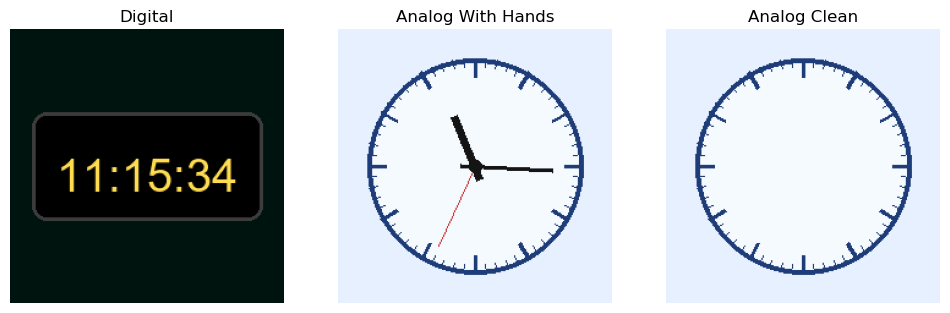

In [91]:
df = pd.read_csv(DATA_DIR / "labels.csv")

print("Total samples:", len(df))
print("\nSamples per style:")
print(df["style_name"].value_counts())

sample = df.sample(1).iloc[0]

digital_img = Image.open(sample["digital_image_path"]).convert("RGB")
analog_hands_img = Image.open(sample["analog_with_hands_path"]).convert("RGB")
analog_clean_img = Image.open(sample["analog_clean_path"]).convert("RGB")

print(f'\nTime: {sample["hour"]:02d}:{sample["minute"]:02d}:{sample["second"]:02d}')
print("Style:", sample["style_name"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()